In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [3]:
## Helper Function

In [4]:
def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()

Decision Tree: 0.9


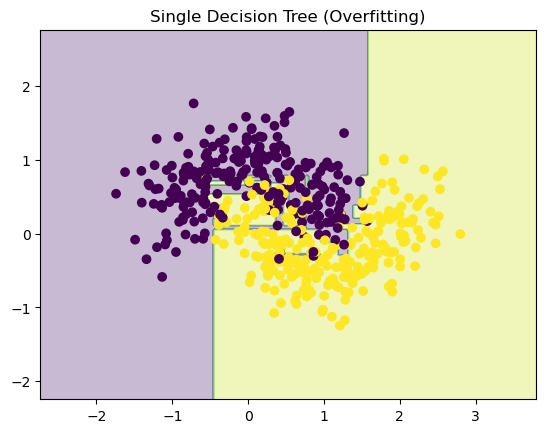

In [5]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print("Decision Tree:", accuracy_score(y_test, dt.predict(X_test)))
plot_boundary(dt, X, y, "Single Decision Tree (Overfitting)")

Bagging Accuracy: 0.92
OOB Score: 0.8771428571428571


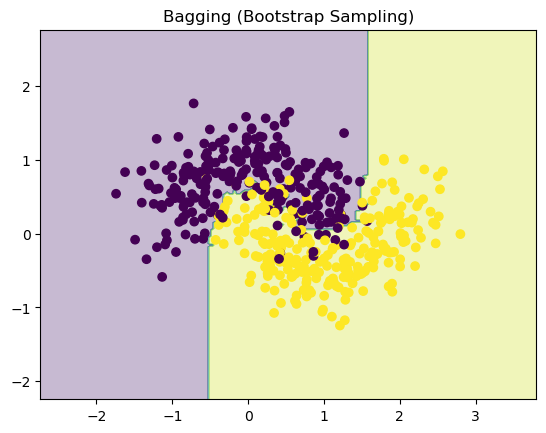

In [7]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True
)

bag.fit(X_train, y_train)

print("Bagging Accuracy:", accuracy_score(y_test, bag.predict(X_test)))
print("OOB Score:", bag.oob_score_)

plot_boundary(bag, X, y, "Bagging (Bootstrap Sampling)")

Pasting Accuracy: 0.9066666666666666


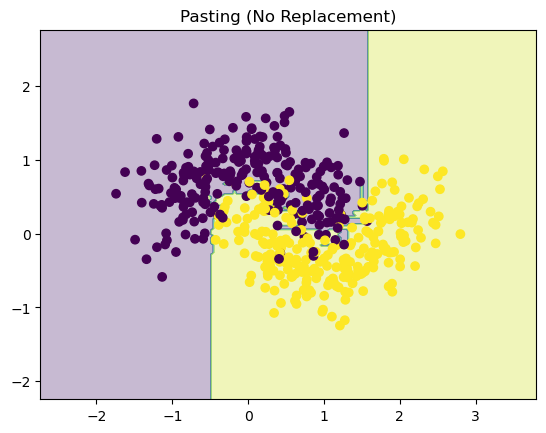

In [8]:
pasting = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=False   # key change
)

pasting.fit(X_train, y_train)

print("Pasting Accuracy:", accuracy_score(y_test, pasting.predict(X_test)))
plot_boundary(pasting, X, y, "Pasting (No Replacement)")

Subspace Accuracy: 0.7466666666666667


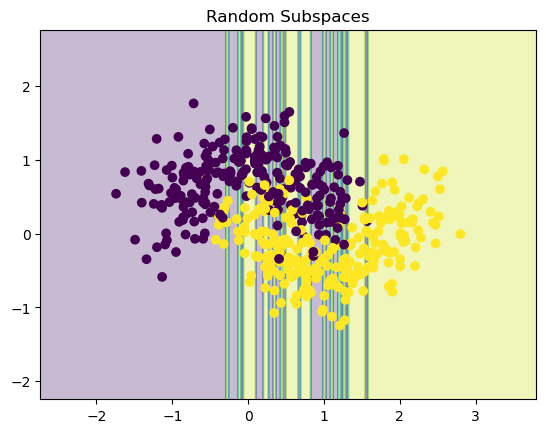

In [9]:
subspace = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_features=1,   # use only 1 feature
    bootstrap=False
)

subspace.fit(X_train, y_train)

print("Subspace Accuracy:", accuracy_score(y_test, subspace.predict(X_test)))
plot_boundary(subspace, X, y, "Random Subspaces")

Random Patches Accuracy: 0.82


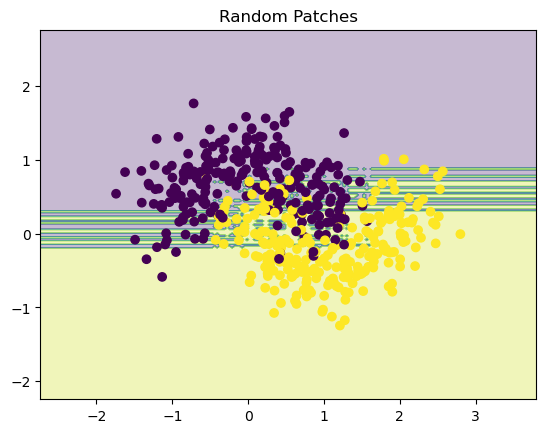

In [11]:
patches = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    max_features=1,
    bootstrap=True
)

patches.fit(X_train, y_train)

print("Random Patches Accuracy:", accuracy_score(y_test, patches.predict(X_test)))
plot_boundary(patches, X, y, "Random Patches")